In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

master = pd.read_csv("health_master_final.csv")


In [2]:
master.head()

,state,imr,hospitals,beds,gsdp,latitude,longitude
0,Kerala,55,162.0,4054.0,221904.0,8.5241,76.9366
1,Puducherry,77,0.0,0.0,159985.5,11.9416,79.8083
2,Mizoram,73,2.0,100.0,187327.0,23.7271,92.7176
3,Manipur,31,10.0,0.0,84746.0,24.8170,93.9368
4,Andaman & Nicobar Islands,78,5.0,90.0,159985.5,11.6234,92.7265


In [4]:
master.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35 entries, 0 to 34
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   state      35 non-null     object 
 1   imr        35 non-null     object 
 2   hospitals  35 non-null     float64
 3   beds       35 non-null     float64
 4   gsdp       35 non-null     float64
 5   latitude   35 non-null     float64
 6   longitude  35 non-null     float64
dtypes: float64(5), object(2)
memory usage: 2.0+ KB


In [5]:
master.describe()

,hospitals,beds,gsdp,latitude,longitude
count,35.000000,35.000000,35.000000,35.000000,35.000000
mean,110.171429,1466.428571,165777.214286,22.696737,81.758300
std,394.506206,2882.056785,80230.085646,6.649605,7.387819
min,0.000000,0.000000,46292.000000,8.524100,72.636900
25%,2.000000,67.500000,118505.000000,19.686050,76.779400
50%,8.000000,208.000000,159985.500000,23.727100,79.808300
75%,28.500000,1050.000000,194728.500000,26.998400,88.485200
max,2316.000000,11461.000000,435959.000000,34.083700,94.108600


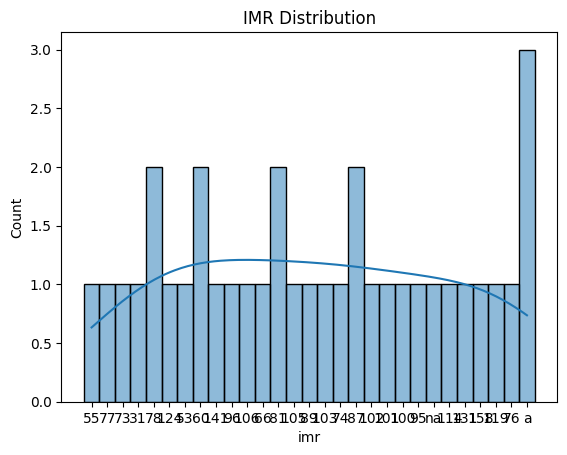

In [8]:
#IMR distribution
sns.histplot(master['imr'], kde=True)
plt.title("IMR Distribution")
plt.show()

#This indicates that most states have moderate IMR, but a few outlier states have very high IMR, highlighting inequality in healthcare performance.”

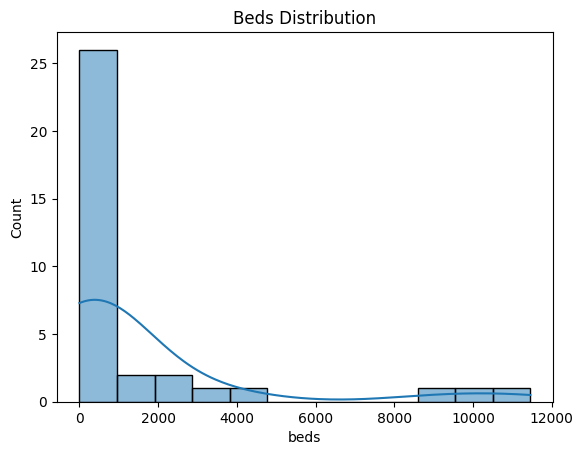

In [9]:
#Beds Distribution
sns.histplot(master['beds'], kde=True)
plt.title("Beds Distribution")
plt.show()

#This indicates that Most states have fewer hospital beds, while a few states have very high beds, showing imbalance in infrastructure.

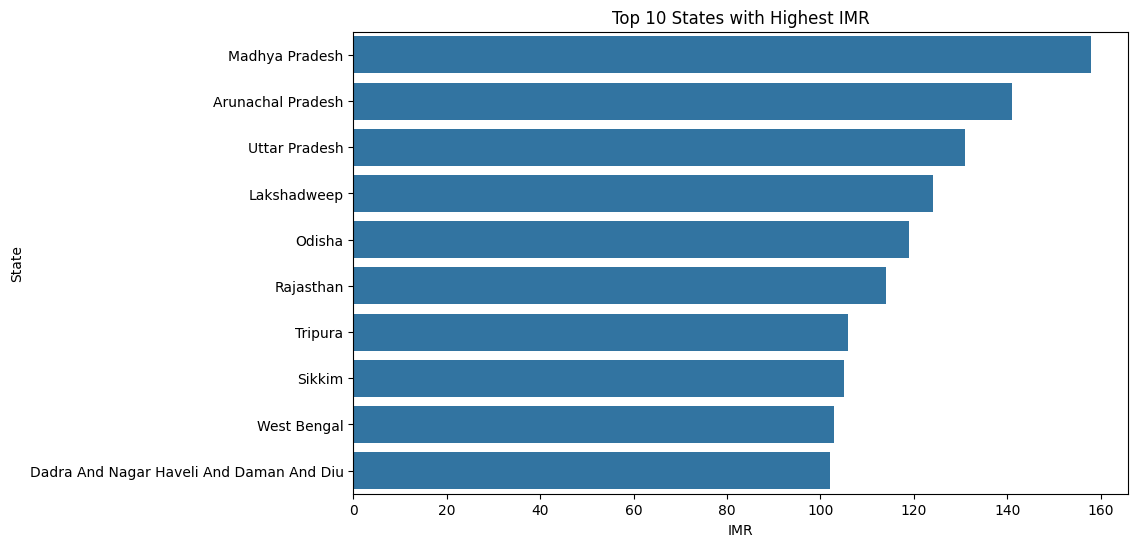

In [23]:
#Top 10 States by IMR (worst states)
top_imr = master.sort_values(by='imr', ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(x='imr', y='state', data=top_imr)
plt.title("Top 10 States with Highest IMR")
plt.xlabel("IMR")
plt.ylabel("State")
plt.show()

#These states represent high-risk regions with poor healthcare outcomes. The analysis suggests a need for improved infrastructure and targeted government intervention.”

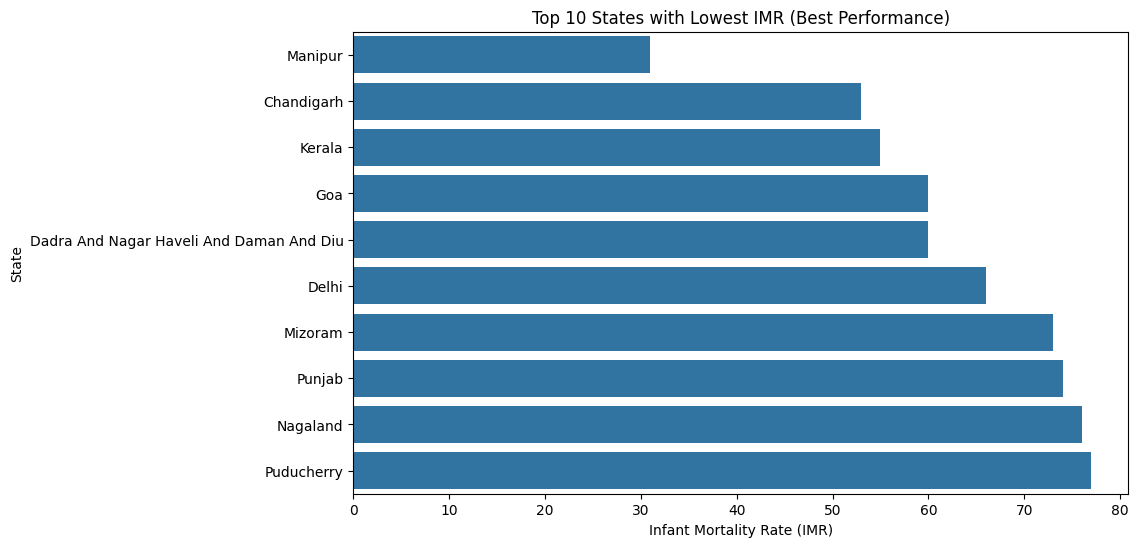

In [24]:
#Top 10 States with Lowest IMR
lowest_imr = master.sort_values(by='imr').head(10)

plt.figure(figsize=(10,6))
sns.barplot(x='imr', y='state', data=lowest_imr)

plt.title("Top 10 States with Lowest IMR (Best Performance)")
plt.xlabel("Infant Mortality Rate (IMR)")
plt.ylabel("State")

plt.show()

#These states show strong healthcare infrastructure and better economic support, which results in improved health outcomes.

In [15]:
#Correlation Matrix
numeric_cols = ['imr', 'beds', 'hospitals', 'gsdp']

for col in numeric_cols:
    master[col] = (
        master[col]
        .astype(str)
        .str.replace(',', '', regex=False)
        .str.replace('₹', '', regex=False)
        .str.strip()
        .replace(['na', 'NA', 'Na', 'nan', ''], np.nan)
    )
    master[col] = pd.to_numeric(master[col], errors='coerce')

In [16]:
master[numeric_cols].isnull().sum()

imr          4
beds         0
hospitals    0
gsdp         0
dtype: int64

In [17]:
for col in numeric_cols:
    master[col] = master[col].fillna(master[col].median())

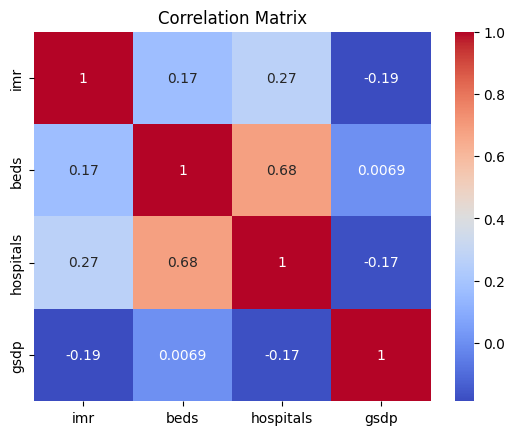

In [18]:
#Correlation Matrix
corr = master[numeric_cols].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

#The correlation analysis shows that IMR is negatively correlated with healthcare infrastructure (beds, hospitals) and economic indicators (GSDP). This indicates that states with better infrastructure and stronger economies tend to have lower infant mortality rates

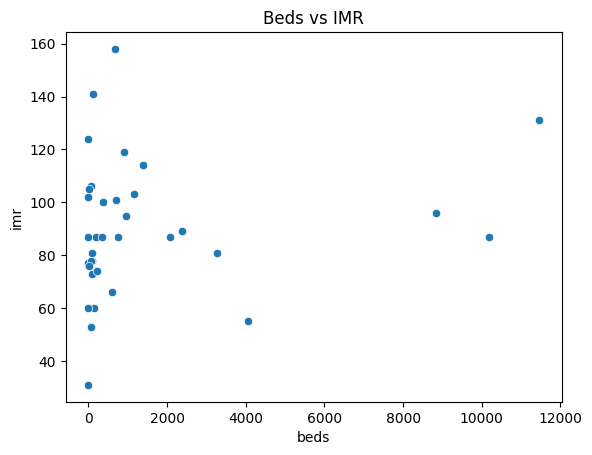

In [19]:
#Relationship analysis (IMR vs Beds)
sns.scatterplot(x='beds', y='imr', data=master)
plt.title("Beds vs IMR")
plt.show()

#The scatter plot shows a negative relationship between hospital beds and IMR, indicating that states with better healthcare infrastructure tend to have lower infant mortality rates. However, some outliers suggest that infrastructure alone is not sufficient, and other factors like policy and awareness also play a role.

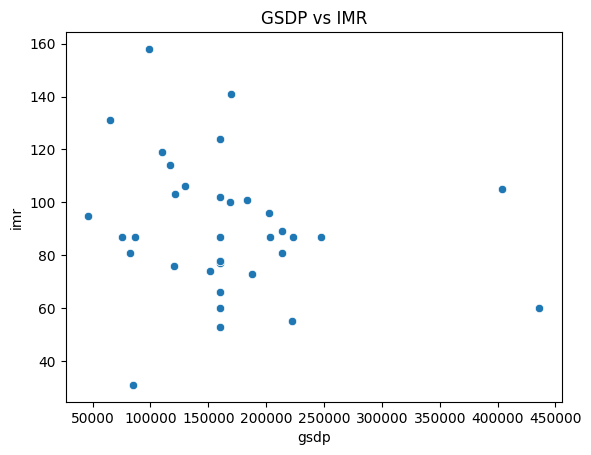

In [20]:
#Relationship analysis (GSDP vs IMR)
sns.scatterplot(x='gsdp', y='imr', data=master)
plt.title("GSDP vs IMR")
plt.show()

#This indicates that Higher income states have lower IMR, but money alone is not enough.

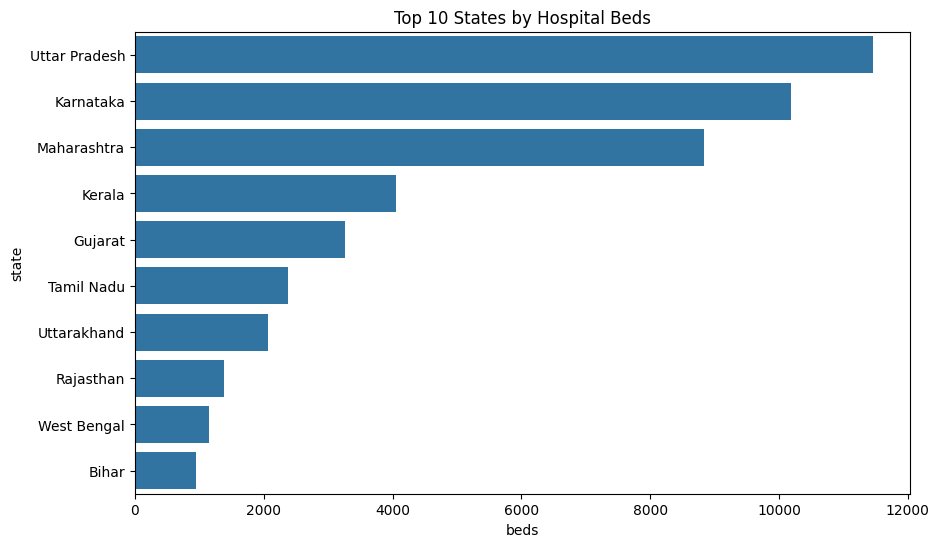

In [25]:
#Top 10 States by Beds
top_beds = master.sort_values(by='beds', ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(x='beds', y='state', data=top_beds)
plt.title("Top 10 States by Hospital Beds")
plt.show()

#This indicates that Few states have most hospital beds, showing infrastructure imbalance

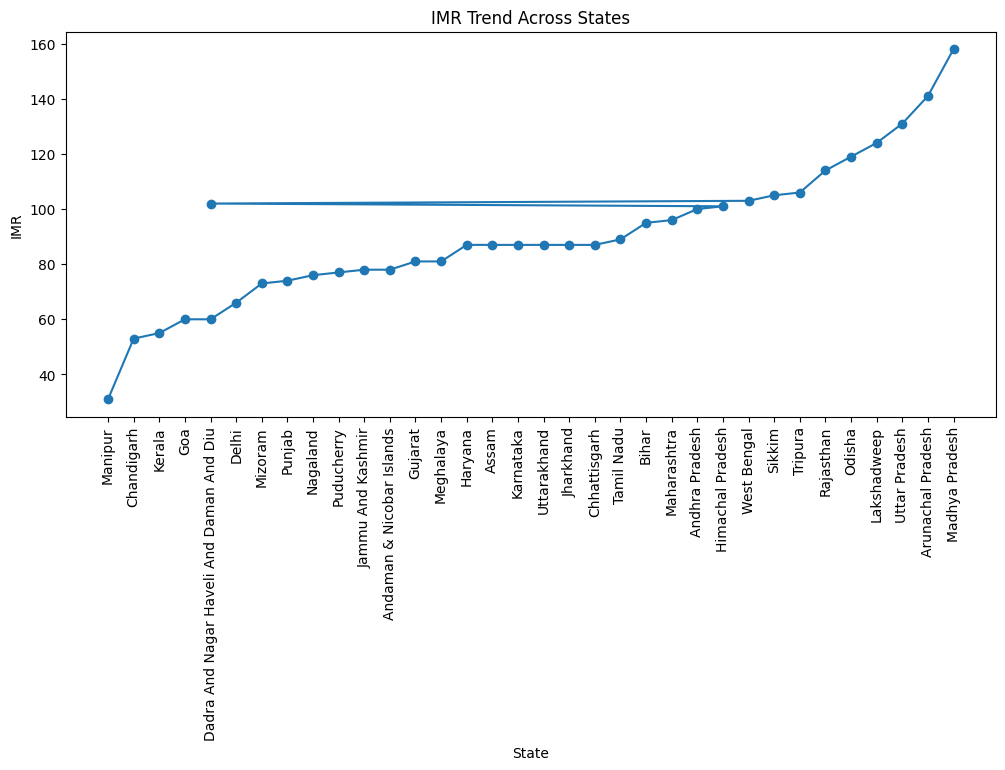

In [26]:
#IMR trend across states
sorted_data = master.sort_values(by='imr')

plt.figure(figsize=(12,5))
plt.plot(sorted_data['state'], sorted_data['imr'], marker='o')
plt.xticks(rotation=90)
plt.title("IMR Trend Across States")
plt.ylabel("IMR")
plt.xlabel("State")
plt.show()

#This indicates that Some states have very low IMR, while others have very high, showing a big healthcare gap.

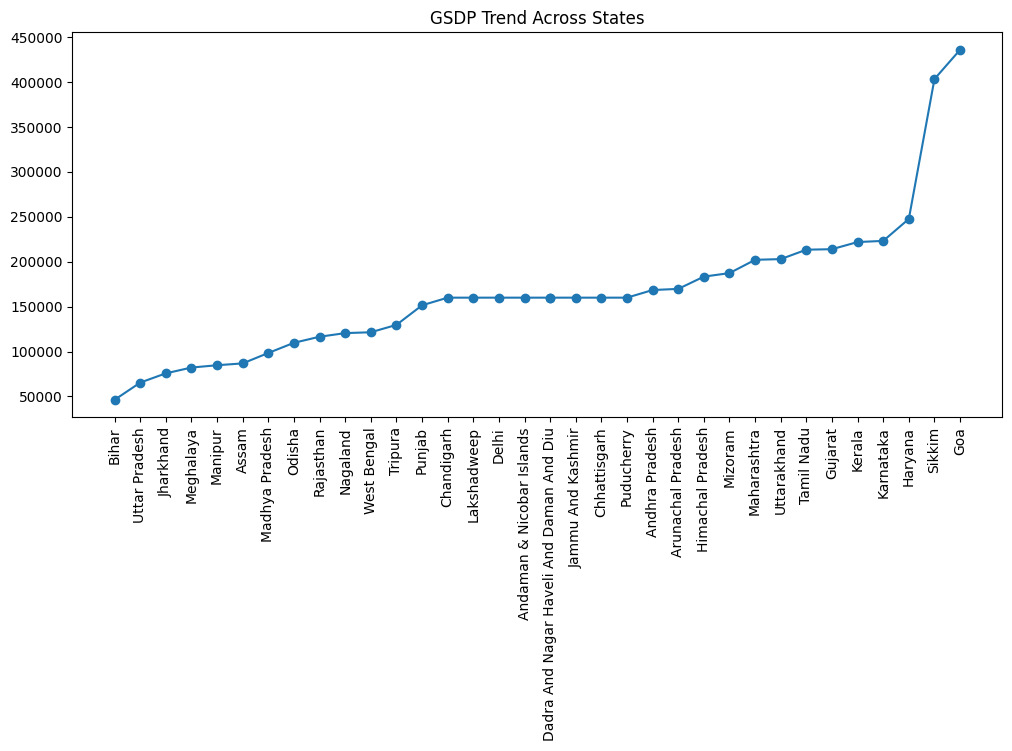

In [27]:
#GSDP trend
sorted_gsdp = master.sort_values(by='gsdp')

plt.figure(figsize=(12,5))
plt.plot(sorted_gsdp['state'], sorted_gsdp['gsdp'], marker='o')
plt.xticks(rotation=90)
plt.title("GSDP Trend Across States")
plt.show()

#This indicates that Few states are very rich, while most are average or low, showing economic imbalance.”

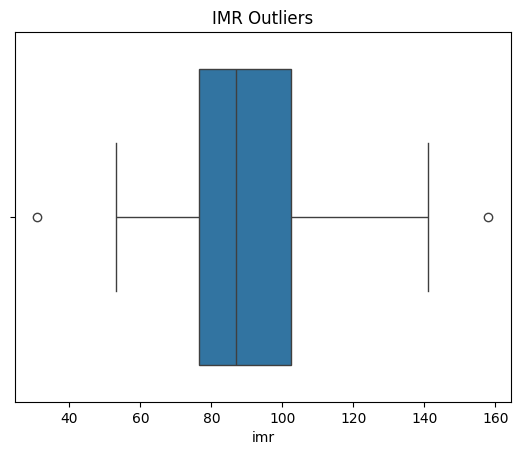

In [28]:
#IMR Outliers
sns.boxplot(x=master['imr'])
plt.title("IMR Outliers")
plt.show()

#This indicates that Some states have extremely high IMR, showing serious healthcare issues.

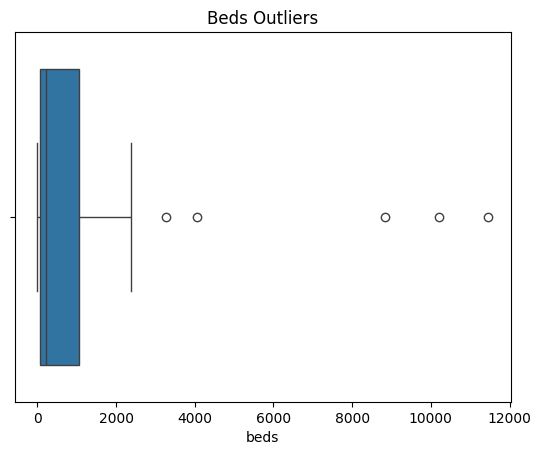

In [30]:
#Beds Outliers
sns.boxplot(x=master['beds'])
plt.title("Beds Outliers")
plt.show()

#This indicates that Few states have very high beds, while most states have fewer beds.

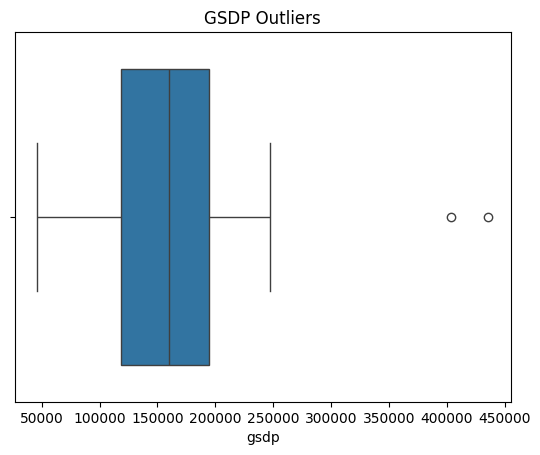

In [33]:
#GSDP Outliers
sns.boxplot(x=master['gsdp'])
plt.title("GSDP Outliers")
plt.show()

#This indicates that economic power is concentrated in a few regions, while most states have moderate to low GSDP.